<a href="https://colab.research.google.com/github/Sarkis55/CA04---Ensemble_Learning_Census_Data/blob/main/CA04_Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Installing sweetviz and Autoviz
pip install sweetviz

In [1]:
#Libaries for Preprocessing and DQA
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import sweetviz as sv

from sklearn.preprocessing import LabelEncoder

#Libraries needed for training, testing and evaluating model
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
#Retrieving data and loading them into dataframe
csv_url = 'https://github.com/ArinB/MSBA-CA-03-Decision-Trees/blob/master/census_data.csv?raw=true'
df = pd.read_csv(csv_url)

display(df.head())

,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,b. 31-40,b. Mid - Low,b. Mid,c. > 0,c. High,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,train,0
1,a. 0-30,e. High,c. High,a. = 0,c. High,c. 13,c. Bachelors,b. income,e. 40-55,train,0
2,b. 31-40,a. Low,b. Mid,a. = 0,c. High,b. 9-12,b. Mid,b. income,d. 36-40 & 56-60,train,0
3,b. 31-40,a. Low,c. High,a. = 0,b. Mid,a. 0-8,a. Low,b. income,e. 40-55,train,0
4,b. 31-40,e. High,c. High,a. = 0,a. Low,c. 13,c. Bachelors,b. income,b. 26-30 & 71-100,train,0


## Preprocessing and DQA

In [3]:
df.shape

(48842, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   hours_per_week_bin  48842 non-null  object
 1   occupation_bin      48842 non-null  object
 2   msr_bin             48842 non-null  object
 3   capital_gl_bin      48842 non-null  object
 4   race_sex_bin        48842 non-null  object
 5   education_num_bin   48842 non-null  object
 6   education_bin       48842 non-null  object
 7   workclass_bin       48842 non-null  object
 8   age_bin             48842 non-null  object
 9   flag                48842 non-null  object
 10  y                   48842 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 4.1+ MB


In [5]:
#Generating a EDA report using python's sweetviz library
report = sv.analyze(df)
report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [6]:
#Checking for Missing Data
df.isnull().sum()

,0
hours_per_week_bin,0
occupation_bin,0
msr_bin,0
capital_gl_bin,0
race_sex_bin,0
education_num_bin,0
education_bin,0
workclass_bin,0
age_bin,0
flag,0


In [7]:
#Getting a value count for each column
for col in df.columns:
  print(f"Value counts for column: {col}")
  print(df[col].value_counts())
  print("\n")

Value counts for column: hours_per_week_bin
hours_per_week_bin
b. 31-40            26639
d. 41-50 & 61-70     9819
a. 0-30              7851
e. 51-60             3759
c. 71-100             774
Name: count, dtype: int64


Value counts for column: occupation_bin
occupation_bin
c. Mid - Mid     13971
b. Mid - Low     12947
e. High          12258
a. Low            7237
d. Mid - High     2429
Name: count, dtype: int64


Value counts for column: msr_bin
msr_bin
c. High    22047
b. Mid     15868
a. Low     10927
Name: count, dtype: int64


Value counts for column: capital_gl_bin
capital_gl_bin
a. = 0    42525
c. > 0     4035
b. < 0     2282
Name: count, dtype: int64


Value counts for column: race_sex_bin
race_sex_bin
c. High    29737
b. Mid     16457
a. Low      2648
Name: count, dtype: int64


Value counts for column: education_num_bin
education_num_bin
b. 9-12    30324
c. 13       8025
a. 0-8      6408
d. 14       2657
e. 15+      1428
Name: count, dtype: int64


Value counts for column: e

In [8]:
#Discretizing features using label encoder.
#Since the majority of the values are object we use encoder to reprsent each value as an integer.

LE = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
      df[col] = LE.fit_transform(df[col])

print("DataFrame after encoding all object columns:")
display(df.head())

#Source: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

DataFrame after encoding all object columns:


,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,1,1,1,2,2,2,2,1,3,1,0
1,0,4,2,0,2,2,2,1,4,1,0
2,1,0,1,0,2,1,1,1,3,1,0
3,1,0,2,0,1,0,0,1,4,1,0
4,1,4,2,0,0,2,2,1,1,1,0


In [9]:
#Getting a value count for each column after encoding
for col in df.columns:
  print(f"Value counts for column: {col}")
  print(df[col].value_counts())
  print("\n")


Value counts for column: hours_per_week_bin
hours_per_week_bin
1    26639
3     9819
0     7851
4     3759
2      774
Name: count, dtype: int64


Value counts for column: occupation_bin
occupation_bin
2    13971
1    12947
4    12258
0     7237
3     2429
Name: count, dtype: int64


Value counts for column: msr_bin
msr_bin
2    22047
1    15868
0    10927
Name: count, dtype: int64


Value counts for column: capital_gl_bin
capital_gl_bin
0    42525
2     4035
1     2282
Name: count, dtype: int64


Value counts for column: race_sex_bin
race_sex_bin
2    29737
1    16457
0     2648
Name: count, dtype: int64


Value counts for column: education_num_bin
education_num_bin
1    30324
2     8025
0     6408
3     2657
4     1428
Name: count, dtype: int64


Value counts for column: education_bin
education_bin
1    30324
2     8025
0     6408
3     2657
4     1428
Name: count, dtype: int64


Value counts for column: workclass_bin
workclass_bin
1    46012
0     2830
Name: count, dtype: int64


Val

<Axes: >

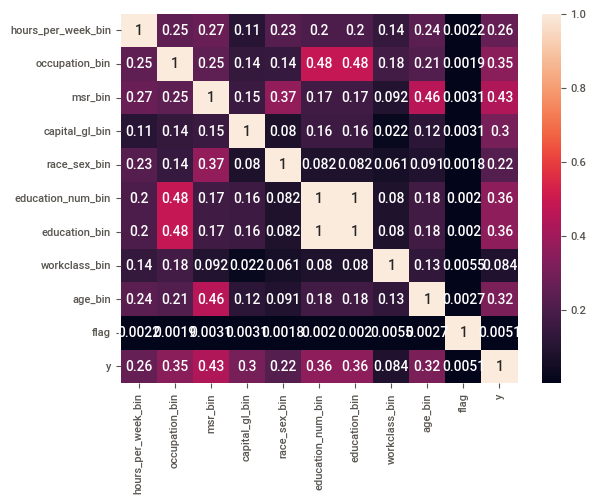

In [10]:
#Heatmap to see feature coorelation
sns.heatmap(df.corr(), annot=True)

In [18]:
#dropping education_bin since it is essentially the same as education_num_bin
df = df.drop('education_bin', axis=1)

In [19]:
#Since we have a column that labels what rows are training and testing, we manually split them by creating two separate dataframes.

#Whatever that is labeled "train" goes to the training dataframe and same for testing
train_df = df[df['flag'] == 1]
test_df = df[df['flag'] == 0]

In [20]:
# Separate the features (X) and target (y).
# We then drop the "flag" column so that the model doesn't cheat by associating a pattern based on a speciifc value
X_train = train_df.drop(['y', 'flag'], axis=1)
y_train = train_df['y']

X_test = test_df.drop(['y', 'flag'], axis=1)
y_test = test_df['y']

#Code generated by Gemini

## Building Randome Forest Model, then finding optimal value of n_estimators

Training the data on a random forest model, then we compare the Accuracy and AUC among different values for the 'n_estimator' hyper parameter, in order to find a value that is optimal.

In [40]:
accuracy_results = []
auc_results = []
n_estimator_options = [50,100,150,200,250,300,350,400,450,500]

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

for n_estimator in n_estimator_options:
  #Training and testing random forest model with each value for 'n_estimator'
  model = RandomForestClassifier(n_estimators = n_estimator, random_state = 101)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  #getting the accuracy and auc score
  accuracy = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred)

  #Storing the results for accuracy and auc after each iteration
  accuracy_results.append(accuracy)
  auc_results.append(float(auc))

print("Accuracy Results:", accuracy_results)
print("AUC Results:", auc_results)

Accuracy Results: [0.8384620109329893, 0.8382163257785148, 0.8382163257785148, 0.8379092193354216, 0.8374792703150912, 0.8379092193354216, 0.8376635341809471, 0.8377863767581843, 0.837847798046803, 0.8384005896443707]
AUC Results: [0.7476130480683643, 0.7471828233804866, 0.7472726194934408, 0.7468919818312636, 0.7451737804132189, 0.7462634090405836, 0.747449514385883, 0.7464523792049391, 0.7463129960662842, 0.7464054895127047]


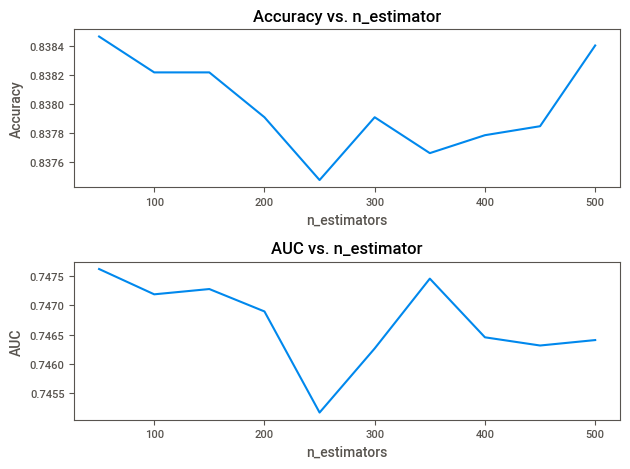

Optimal estimator Random Forest Accuracy: ( 50 , 0.8384620109329893 )
Optimal estimator and Random Forest AUC: ( 50 , 0.7476130480683643 )


In [42]:
#Plotting line graphs for Accuracy vs.n_estimator, and AUC Vs.n_estimator

fig, (ax1, ax2) = plt.subplots(2)

ax1.plot(n_estimator_options, accuracy_results)
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs. n_estimator')

ax2.plot(n_estimator_options, auc_results)
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('AUC')
ax2.set_title('AUC vs. n_estimator')

plt.tight_layout()
plt.show()

#Storing best random forest accuacy and auc scores
best_rf_accuracy = max(accuracy_results)
best_rf_auc = max(auc_results)

#Printing best accuracy and auc and its respective estimator value
print("Optimal estimator Random Forest Accuracy: (", n_estimator_options[accuracy_results.index(best_rf_accuracy)], ',', best_rf_accuracy, ")")
print("Optimal estimator and Random Forest AUC: (", n_estimator_options[auc_results.index(best_rf_auc)], ',', best_rf_auc, ")")

#### 1. Write your observations about the Classifier’s behavior with respect to the number of estimators.
*   Based on the graphs, the values for both AUC and accuracy seems to flucuate as the number of estimators inceases, but at a very slight variation of less than 0.1%. Therefore the performance of the random forest classifier seems to plateau if we keep all other hyperparameters as default values.

#### 2. Is there an optimal value of the estimator within the given range?
*   Based on the two graphs, the optimal value of the estimator is 50, which gives an accuracy of 0.838 and AUC of 0.748.



## Building Gradient Boost Model, then recording optimal estimator